In [15]:
import geopandas as gpd
borders = gpd.read_file('borders/ne_10m_admin_0_boundary_lines_land.shp')

In [20]:
counties = gpd.read_file('counties/Counties_Shoreline.shp')
counties = counties.to_crs('EPSG:4326')
counties.to_file('counties.geojson', driver='GeoJSON')

In [31]:
roads = gpd.read_file('ne_10m_roads/ne_10m_roads.shp')
filtered_roads = roads[roads['type'].isin(['Major Highway', 'Secondary Highway', 'Beltway', 'Road'])]

In [30]:
roads['type'].value_counts()

type
Unknown              25766
Road                 11531
Major Highway         9752
Secondary Highway     9025
Ferry Route            309
Beltway                168
Track                   39
Bypass                   5
Ferry, seasonal          5
Name: count, dtype: int64

In [32]:
filtered_roads.to_file('roads.geojson', driver='GeoJSON')

In [3]:
borders.to_file('borders.geojson', driver='GeoJSON')

<Axes: >

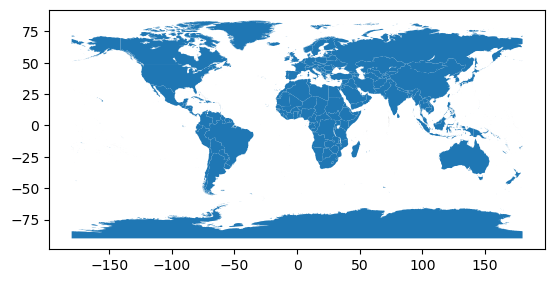

In [4]:
land = gpd.read_file('countries_lakes/ne_10m_admin_0_countries_lakes.shp')
land.plot()

In [5]:
adm1borders = gpd.read_file('state-borders/ne_10m_admin_1_states_provinces_lines.shp')

In [6]:
stateborders = adm1borders[adm1borders['ADM0_A3']=='USA']

In [7]:
stateborders = stateborders.to_crs(land.crs)
cropped_lines = gpd.clip(stateborders, land)

/opt/anaconda3/envs/geospatial/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


In [14]:
cropped_lines = cropped_lines[cropped_lines.length > 0.1]
cropped_lines.explore()

/var/folders/vb/g3gswtld4t51802bphwpn63h0000gn/T/ipykernel_53618/153014266.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cropped_lines = cropped_lines[cropped_lines.length > 0.1]
/opt/anaconda3/envs/geospatial/lib/python3.14/site-packages/folium/features.py:1204: UserWarning: GeoJsonTooltip is not configured to render for GeoJson GeometryCollection geometries. Please consider reworking these features: [{'FEATURECLA': 'Admin-1 boundary indicator', 'NAME': None, 'ADM0_A3': 'USA', 'ADM0_NAME': 'United States of America', 'SHAPE_LENG': None, 'MAPCOLOR13': 1.0, 'MAPCOLOR9': 1.0, 'SOV_A3': 'US1', 'NAME_L': None, 'NAME_R': None, 'NAME_ALT_L': None, 'NAME_ALT_R': None, 'NAME_LOC_L': None, 'NAME_LOC_R': None, 'NAME_LEN_L': None, 'NAME_LEN_R': None, 'NOTE': None, 'TYPE': None, 'MIN_ZOOM': 2.0, 'MIN_LABEL': 7.5, 'SCALERANK': 9, 'FCLASS_ISO': None, 'FCLAS

In [9]:
stateborders.to_file('stateborders.geojson', driver='GeoJSON')